# 26_01 Z-score 이상탐지 해석

In [10]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


### 실습 1. MIMII 데이터 불러오기·구조 확인
목표 : 데이터를 불러와 크기와 정답 분포를 확인

단계
- 특징값 파일을 불러오기
- 크기로 행·열 개수를 확인
- 정답 분포로 정상·이상 개수를 확인

예상 결과
- 220행 4열, 정상 180·이상 40


In [11]:
# 실습1 코드
MI = "26_mimii_features.csv"
df = pd.read_csv(MI)

print("크기:", df.shape)
normal = df[df["label"] == 0]
abnormal = df[df["label"] == 1]
print("정상:", len(normal), "이상:", len(abnormal))

크기: (220, 4)
정상: 180 이상: 40


### 실습 2. 특징값 분포 정상·이상 비교
목표 : 한 특징의 분포를 정상·이상 색으로 나눠 그려 차이를 보기

단계
- 특징 하나를 히스토그램으로 그리기
- 정답으로 색을 나눠 겹쳐 그리기
- 정상·이상 분포가 어디서 갈리는지 관찰

예상 결과
- 이상은 정상보다 값이 큰 쪽으로 분포가 치우침


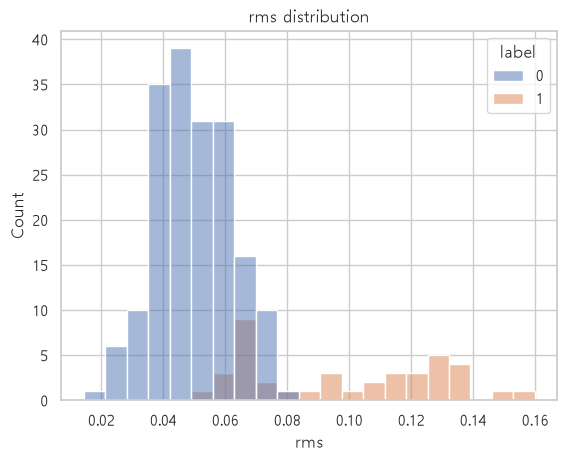

In [12]:
# 실습2 코드
sns.histplot(data=df, x='rms', hue='label')
plt.title("rms distribution")
plt.show()

### 실습 3. 정상 데이터 기준선 세우기
목표 : 정상만 골라 특징별 평균·표준편차로 기준선을 세우기

단계
- 정답이 정상인 행만 골라내기
- 정상 개수를 확인
- 세 특징의 평균과 표준편차를 출력

예상 결과
- 정상 180개, rms 평균 0.05·표준편차 0.012 등


In [13]:
# 실습3 코드
print('정상 개수:', len(normal))

for f in ['rms', 'spectral_centroid', 'zero_crossing_rate']:
    print(f, round(normal[f].mean(), 3), round(normal[f].std(), 3))

정상 개수: 180
rms 0.05 0.012
spectral_centroid 1979.099 239.176
zero_crossing_rate 0.091 0.019


### 실습 4. rms Z-score 계산과 최댓값
목표 : rms를 정상 기준으로 Z-score로 바꾸고 가장 튄 값을 찾기

단계
- 정상 평균·표준편차로 Z-score를 계산
- 결과를 새 열로 담기
- Z가 큰 순으로 정렬해 가장 튄 샘플 확인

예상 결과
- 가장 튄 Z가 약 9로 정상에서 크게 벗어남


In [14]:
# 실습4 코드
rms_mean = normal['rms'].mean()
rms_std = normal['rms'].std()

df['z_rms'] = (df['rms'] - rms_mean) / rms_std

top = df.sort_values('z_rms', ascending=False)[['rms', 'z_rms', 'label']].head(3)
print(top.round(2).to_string(index=False))

 rms  z_rms  label
0.16   9.01      1
0.15   7.92      1
0.14   7.21      1


### 실습 5. 임계값 적용과 2·3 비교
목표 : 절댓값 기준으로 이상을 표시하고 임계값 2와 3 결과를 비교

단계
- Z의 절댓값을 구하기
- 절댓값이 3을 넘으면 이상으로 표시
- 임계값 2와 3의 탐지 개수를 비교

예상 결과
- 임계값 3은 23건, 2는 36건 (낮출수록 많이 잡힘)

In [15]:
# 실습5 코드
df['z_abs'] = df['z_rms'].abs()

df['is_anomaly'] = df['z_abs'] > 3.0
df['is_anomaly_2'] = df['z_abs'] > 2.0

print('임계값 3:', int(df['is_anomaly'].sum()))
print('임계값 2:', int(df['is_anomaly_2'].sum()))

임계값 3: 23
임계값 2: 36


### 실습 6. 세 특징 종합 판정
목표: 세 특징에 각각 Z-score를 적용하고 하나라도 넘으면 이상으로 종합

단계
- 세 특징마다 정상 기준으로 Z를 계산
- 특징 중 하나라도 절댓값이 3을 넘으면 이상 표시
- rms 단독 결과와 종합 결과를 비교

예상 결과
- 종합 이상은 39건으로 rms 단독 23건보다 많음

In [16]:
# 실습6 코드

# df의 index갯수만큼 False로 채워진 Series를 만듭니다
is_any = pd.Series(False, index=df.index)

for f in ['rms', 'spectral_centroid', 'zero_crossing_rate']:
    z = (df[f] - normal[f].mean()) / normal[f].std()
    is_any = is_any | (np.abs(z) > 3.0)

print('종합 이상:', int(is_any.sum()))

종합 이상: 39


### 실습 7. 탐지 결과 정비 문장으로 정리
목표: 가장 튄 이상 샘플을 사람이 읽을 정비 문장으로 옮기기

단계
- 이상으로 표시된 것 중 Z 절댓값 상위 몇 개 고르기
- 각 샘플의 벗어난 방향과 배수를 확인
- 점검 권장 문장으로 출력

예상 결과
- 소리 세기가 표준편차 몇 배 위로 벗어남, 점검 권장 문장

In [ ]:
# 실습7 코드
hits = df[df['is_anomaly']].sort_values('z_abs', ascending=False).head(3)
# print(hits)

for i, row in hits.iterrows():
    direction = '위' if row['z_rms'] > 0 else '아래'
    print(f"{i}번: 소리 세기가 표준편차 {row['z_abs']:.1f}배 {direction}로 벗어남, 점검 권장")

        rms  spectral_centroid  zero_crossing_rate  label     z_rms     z_abs  \
70   0.1599             1947.0              0.0891      1  9.005796  9.005796   
108  0.1467             2674.4              0.1037      1  7.924391  7.924391   
192  0.1380             2521.8              0.1060      1  7.211646  7.211646   

     is_anomaly  is_anomaly_2  
70         True          True  
108        True          True  
192        True          True  
70번: 소리 세기가 표준편차 9.0배 위로 벗어남, 점검 권장
108번: 소리 세기가 표준편차 7.9배 위로 벗어남, 점검 권장
192번: 소리 세기가 표준편차 7.2배 위로 벗어남, 점검 권장


### 실습 8. Z-score가 놓친 이상 확인
목표: rms 하나로는 놓친 진짜 이상을 찾고 두 특징 산점도로 확인

단계
- 임계값을 넘지 않았는데 실제로는 이상인 샘플을 골라내기
- 놓친 개수를 세기
- 두 특징 산점도에서 정상 속 이상 위치 확인

예상 결과
- rms 단독으로 17건을 놓침 — 한 특징만으로는 부족

놓친 이상: 17


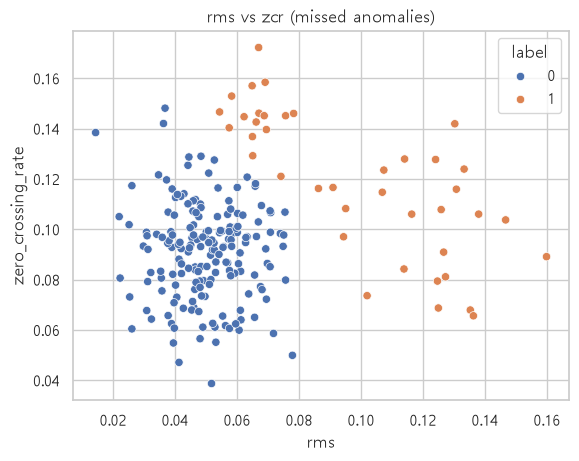

In [18]:
#실습8 코드
missed = df[(df['z_abs'] <= 3.0) & (df['label'] == 1)]
print('놓친 이상:', len(missed))

sns.scatterplot(data=df, x='rms', y='zero_crossing_rate', hue='label')
plt.title('rms vs zcr (missed anomalies)')
plt.show()